# LSTM Strategy Implementation
This notebook implements a Long Short-Term Memory (LSTM) model for time-series prediction of NIFTY direction.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.ml_models import get_lstm_model
from src.data_utils import load_data

# Ensure models/plots directories exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../plots", exist_ok=True)


In [2]:
# 1. Load Data
df = pd.read_csv("../results/baseline_results.csv", index_col=0, parse_dates=True)
# Ensure Market_Returns exists
if 'Market_Ret' in df.columns and 'Market_Returns' not in df.columns:
    df.rename(columns={'Market_Ret': 'Market_Returns'}, inplace=True)

print(f"Data Loaded: {df.shape}")


Data Loaded: (4228, 33)


In [3]:
# 2. Feature Selection & Scaling
features = ['Close', 'Delta_CE', 'Delta_PE', 'Gamma', 'Vega', 'PCR_OI', 'Regime', 'Avg_IV']
target_col = 'Target'

# Create Binary Target: 1 if Next Return > 0
df['Target'] = (df['Market_Returns'].shift(-1) > 0).astype(int)

df = df.dropna()
data = df[features].values
y = df[target_col].values

# Scale features to (0, 1) for LSTM
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Save scaler for later if needed
import joblib
joblib.dump(scaler, "../models/scaler_lstm.pkl")


['../models/scaler_lstm.pkl']

In [4]:
# 3. Create Sequences
SEQ_LEN = 60  # Lookback window (e.g., 60 bars = 5 hours)

def create_sequences(data, labels, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_len):
        X_seq.append(data[i:i+seq_len])
        y_seq.append(labels[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(data_scaled, y, SEQ_LEN)
print(f"Sequences created. X: {X_seq.shape}, y: {y_seq.shape}")


Sequences created. X: (4167, 60, 8), y: (4167,)


In [5]:
# 4. Train/Test Split (Time Series Split)
split = int(len(X_seq) * 0.7)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (2916, 60, 8)
Test shape: (1251, 60, 8)


In [6]:
# 5. Build and Train LSTM Model
model = get_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))

if model:
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )
    
    # Save Model
    model.save("../models/lstm_model.h5")
    print("Model saved to ../models/lstm_model.h5")
else:
    print("Model creation failed.")


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


 1/92 ━━━━━━━━━━━━━━━━━━━━ 5:03 3s/step - accuracy: 0.3750 - loss: 0.7009

 3/92 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4427 - loss: 0.6955

 5/92 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4725 - loss: 0.6939

...

87/92 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5081 - loss: 0.6924

89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5082 - loss: 0.6924

91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5082 - loss: 0.6924

92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5099 - loss: 0.6927 - val_accuracy: 0.4772 - val_loss: 0.6967


Model saved to ../models/lstm_model.h5


 1/92 ━━━━━━━━━━━━━━━━━━━━ 28s 309ms/step

 5/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step  

 9/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

13/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

17/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

...

26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


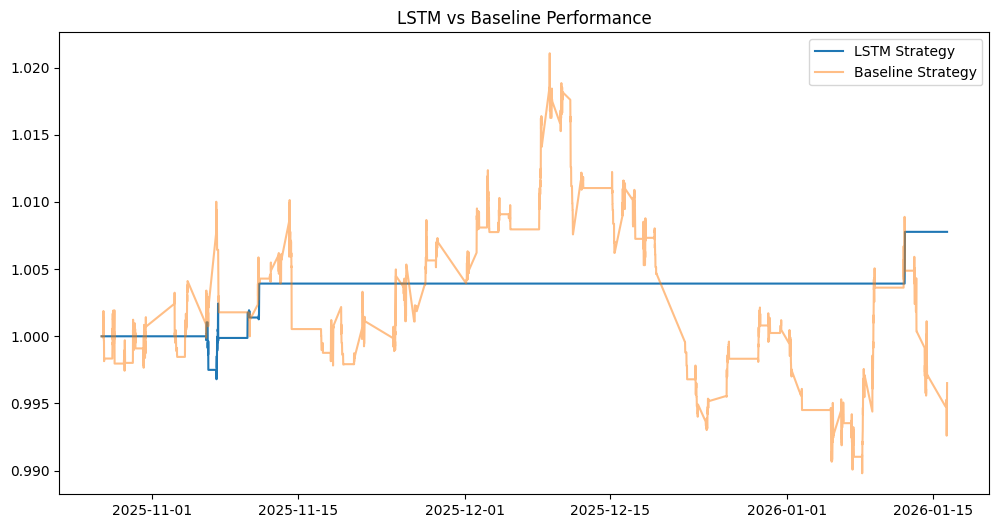

Results saved.


In [7]:
# 6. Backtest / Evaluation
if model:
    # Predict Probabilities
    train_probs = model.predict(X_train).flatten()
    test_probs = model.predict(X_test).flatten()
    
    # Align predictions with original dataframe indices
    # Note: We lost the first SEQ_LEN data points due to sequence creation
    # And split happens after that.
    
    # Create a Series for plotting
    full_probs = np.concatenate([np.full(SEQ_LEN, np.nan), train_probs, test_probs])
    
    # Ensure length matches df (it might differ by a few rows if math is off, so handle carefully)
    # len(df) = len(X_seq) + SEQ_LEN
    # len(full_probs) = len(train) + len(test) + SEQ_LEN = len(X_seq) + SEQ_LEN = len(df)
    
    df['LSTM_Prob'] = full_probs
    
    # Strategy Logic: Long if Prob > 0.6, Short if Prob < 0.4 (Example)
    df['LSTM_Signal'] = 0
    df.loc[df['LSTM_Prob'] > 0.55, 'LSTM_Signal'] = 1
    df.loc[df['LSTM_Prob'] < 0.45, 'LSTM_Signal'] = -1
    
    # Returns
    df['LSTM_Returns'] = df['LSTM_Signal'].shift(1) * df['Market_Returns']
    
    # Plot Cumulative Returns
    plt.figure(figsize=(12, 6))
    plt.plot((1 + df['LSTM_Returns'].fillna(0)).cumprod(), label='LSTM Strategy')
    plt.plot((1 + df['Strategy_Ret'].fillna(0)).cumprod(), label='Baseline Strategy', alpha=0.5)
    plt.title("LSTM vs Baseline Performance")
    plt.legend()
    plt.savefig("../plots/lstm_performance.png")
    plt.show()
    
    # Save Results
    df.to_csv("../results/lstm_results.csv")
    print("Results saved.")
